In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

ACC_PATH  = DATA_DIR / "raw" / "test_1" / "log_t0_acc_1_test.txt"
GYRO_PATH = DATA_DIR / "raw" / "test_1" / "log_t0_gyro_1_test.txt"

In [24]:
def read_imu_log(path, cols):
    return pd.read_csv(
        path,
        comment="%",
        sep=r"\s+",
        header=None,
        names=cols,
        engine="python"
    ).dropna().sort_values(cols[0]).drop_duplicates(cols[0])

acc  = read_imu_log(ACC_PATH,  ["t","ax","ay","az"])
gyro = read_imu_log(GYRO_PATH, ["t","gx","gy","gz"])
acc.head(), gyro.head()

(              t      ax      ay      az
 0  1.766402e+09 -0.2197  0.4885  0.8680
 1  1.766402e+09 -0.2186  0.4834  0.8612
 2  1.766402e+09 -0.2188  0.4893  0.8601
 3  1.766402e+09 -0.2168  0.4866  0.8627
 4  1.766402e+09 -0.2174  0.4871  0.8577,
               t      gx      gy      gz
 0  1.766402e+09 -3.6364 -9.6412 -1.8716
 1  1.766402e+09 -3.4580 -9.4886 -1.4763
 2  1.766402e+09 -3.2906 -9.4581 -1.7474
 3  1.766402e+09 -3.3322 -9.4581 -1.4742
 4  1.766402e+09 -3.6623 -9.4886 -1.6574)

In [25]:
t0 = min(acc["t"].iloc[0], gyro["t"].iloc[0])
acc["t_rel"]  = acc["t"]  - t0
gyro["t_rel"] = gyro["t"] - t0

acc.head(), gyro.head()

(              t      ax      ay      az   t_rel
 0  1.766402e+09 -0.2197  0.4885  0.8680  0.0011
 1  1.766402e+09 -0.2186  0.4834  0.8612  0.0122
 2  1.766402e+09 -0.2188  0.4893  0.8601  0.0246
 3  1.766402e+09 -0.2168  0.4866  0.8627  0.0365
 4  1.766402e+09 -0.2174  0.4871  0.8577  0.0485,
               t      gx      gy      gz   t_rel
 0  1.766402e+09 -3.6364 -9.6412 -1.8716  0.0000
 1  1.766402e+09 -3.4580 -9.4886 -1.4763  0.0121
 2  1.766402e+09 -3.2906 -9.4581 -1.7474  0.0245
 3  1.766402e+09 -3.3322 -9.4581 -1.4742  0.0364
 4  1.766402e+09 -3.6623 -9.4886 -1.6574  0.0485)

In [26]:
def qc(df, tcol="t"):
    dt = df[tcol].diff().dropna()
    return {
        "n": len(df),
        "duration_s": float(df[tcol].iloc[-1] - df[tcol].iloc[0]),
        "dt_min": float(dt.min()),
        "dt_med": float(dt.median()),
        "dt_max": float(dt.max()),
        "fs_med_hz": float(1.0 / dt.median())
    }

print("ACC:", qc(acc))
print("GYRO:", qc(gyro))

ACC: {'n': 12437, 'duration_s': 149.2332000732422, 'dt_min': 0.010899782180786133, 'dt_med': 0.012000083923339844, 'dt_max': 0.013100147247314453, 'fs_med_hz': 83.33275053643806}
GYRO: {'n': 12437, 'duration_s': 149.23430013656616, 'dt_min': 0.010899782180786133, 'dt_med': 0.012000083923339844, 'dt_max': 0.013200044631958008, 'fs_med_hz': 83.33275053643806}


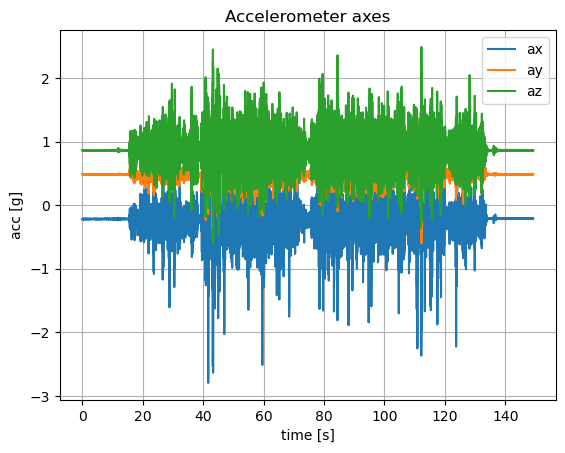

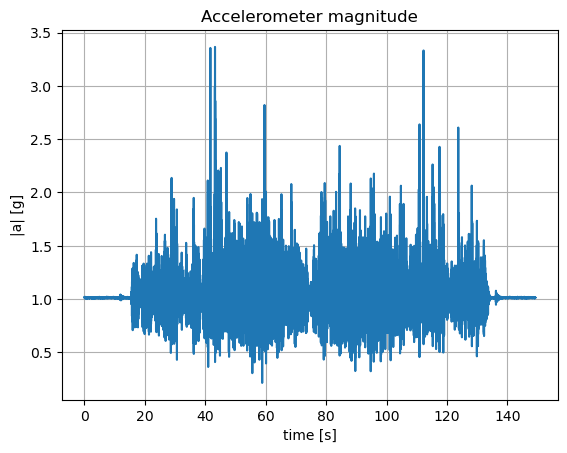

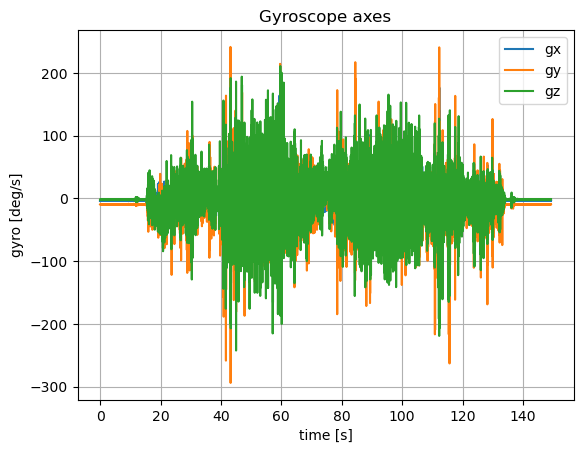

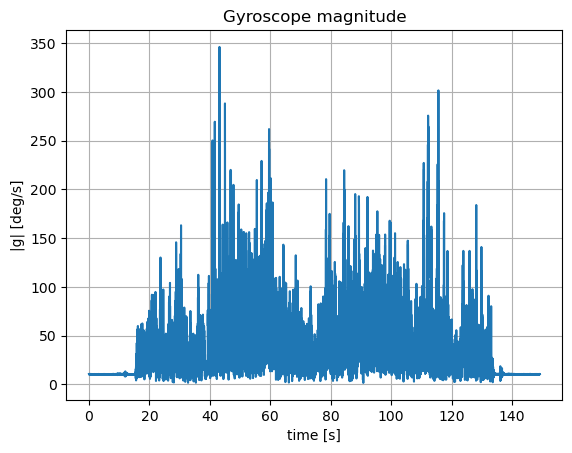

In [28]:
def plot_imu_sanity(acc, gyro, tcol="t_rel"):
    # -------- ACC axes --------
    plt.figure()
    plt.plot(acc[tcol], acc["ax"], label="ax")
    plt.plot(acc[tcol], acc["ay"], label="ay")
    plt.plot(acc[tcol], acc["az"], label="az")
    plt.xlabel("time [s]")
    plt.ylabel("acc [g]")
    plt.title("Accelerometer axes")
    plt.legend()
    plt.grid(True)

    # -------- ACC magnitude --------
    plt.figure()
    acc_mag = np.sqrt(acc["ax"]**2 + acc["ay"]**2 + acc["az"]**2)
    plt.plot(acc[tcol], acc_mag)
    plt.xlabel("time [s]")
    plt.ylabel("|a| [g]")
    plt.title("Accelerometer magnitude")
    plt.grid(True)

    # -------- GYRO axes --------
    plt.figure()
    plt.plot(gyro[tcol], gyro["gx"], label="gx")
    plt.plot(gyro[tcol], gyro["gy"], label="gy")
    plt.plot(gyro[tcol], gyro["gz"], label="gz")
    plt.xlabel("time [s]")
    plt.ylabel("gyro [deg/s]")
    plt.title("Gyroscope axes")
    plt.legend()
    plt.grid(True)

    # -------- GYRO magnitude --------
    plt.figure()
    gyro_mag = np.sqrt(gyro["gx"]**2 + gyro["gy"]**2 + gyro["gz"]**2)
    plt.plot(gyro[tcol], gyro_mag)
    plt.xlabel("time [s]")
    plt.ylabel("|g| [deg/s]")
    plt.title("Gyroscope magnitude")
    plt.grid(True)

    plt.show()

plot_imu_sanity(acc, gyro)